In [94]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import json
from matplotlib.colors import Normalize

from collections import defaultdict

In [95]:
# FOLDER = '/Users/juliuswuerzler/Documents/Uni/Master/MasterThesis/results/12_17_13_30_trial_-1' # BASELINE
# FOLDER = '/Users/juliuswuerzler/Documents/Uni/Master/MasterThesis/results/12_18_10_45_trial_-1' # SILENT FB

# FOLDER = '/Users/juliuswuerzler/Documents/Uni/Master/MasterThesis/results/12_17_14_01_trial_-1' # HARD WMAX
# FOLDER = '/Users/juliuswuerzler/Documents/Uni/Master/MasterThesis/results/12_17_14_39_trial_-1' # HARD WMAX + LOWER A_LTD
# FOLDER = '/Users/juliuswuerzler/Documents/Uni/Master/MasterThesis/results/12_17_14_54_trial_-1'# SAME AS BEFORE FOR SEED 4
# FOLDER = '/Users/juliuswuerzler/Documents/Uni/Master/MasterThesis/results/12_18_10_02_trial_-1/Trial_1' # SAME AS BEFORE FOR SEED 1
# FOLDER = '/Users/juliuswuerzler/Documents/Uni/Master/MasterThesis/results/12_18_10_02_trial_-1/Trial_3' # SAME AS BEFORE FOR SEED 3

### EXP
FOLDER = '/Users/juliuswuerzler/Documents/Uni/Master/MasterThesis/results/01_21_19_56_trial_-1_250_3perstim_2inputs'
TRIAL = 8

In [96]:
data = {}

for file in os.listdir(FOLDER):
    file_name = os.path.join(FOLDER, file)
        
    if f"_{TRIAL}_weights.csv" in file_name:
        loaded_data = np.genfromtxt(file_name, delimiter=',', names=True, dtype=None, encoding='utf-8')
        data['pre'] = loaded_data['pre']
        data['post'] = loaded_data['post']
    
    if f"_{TRIAL}_weights_time.npy" in file_name:
        data['ws'] = np.load(file_name)
        
    if f"_{TRIAL}_neuron_ids" in file_name:
        with open(file_name, "r") as f:
            neuron_ids = json.load(f)
            data['ids'] = neuron_ids
            
    if f"_{TRIAL}_simulation_states" in file_name:
        sim_states = np.genfromtxt(file_name, delimiter=',', names=True, dtype=None, encoding='utf-8')
        data['sim states'] = sim_states
        
    if f"_{TRIAL}_rates_time.npy" in file_name:
        data['rs'] = np.load(file_name)

KeyError: 'ids'

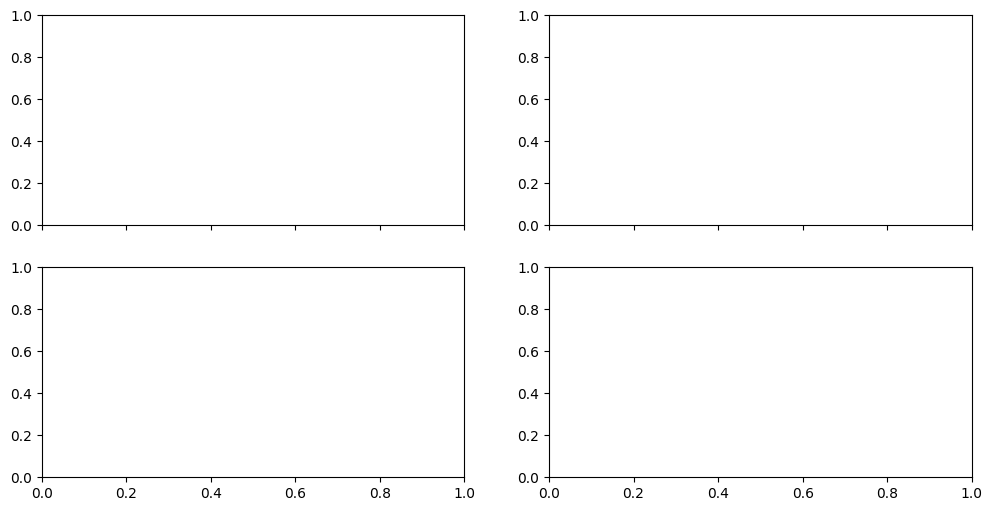

In [97]:
# plot the weights of all stimulation ids
fig, axs = plt.subplots(2, 2, figsize=(12,6), sharex=True)

for i, (stim_id, ax) in enumerate(zip(data['ids']['stimulation_ids'], axs)):
    
    pre_mask = data['pre'] == stim_id
    print(np.sum(pre_mask))
    
    U_mask = np.isin(data['post'], data['ids']['motor_ids_U']) & pre_mask
    D_mask = np.isin(data['post'], data['ids']['motor_ids_D']) & pre_mask
    other_mask = pre_mask & ~(U_mask | D_mask)
    
    xs = np.arange(0, data['ws'].shape[1]) * 0.05
    ax[0].plot(xs, data['ws'][other_mask].T, color='gray', alpha=0.4)
    ax[0].plot(xs, data['ws'][U_mask].T, color='dodgerblue', alpha=0.8, linewidth=3)
    ax[0].plot(xs, data['ws'][D_mask].T, color='orchid', alpha=0.8, linewidth=3)
    
    ax[1].plot(xs, data['ws'][pre_mask].sum(axis=0))
    ax[1].axhline(1.2)
    
    # ax.set_title(f'stim_id {i}')
    
    time = 900
    for i, sim_state in enumerate(data['sim states']):
        if sim_state[-1] == 'running':
            time += 0.05
        if sim_state[-1] == 'miss':
            ax[0].axvspan(time, time+8, alpha = 0.2, color='red')
            ax[1].axvspan(time, time+8, alpha = 0.2, color='red')
            time += 8
        if sim_state[-1] == 'hit':
            ax[0].axvspan(time, time+0.1, alpha = 0.5, color='limegreen')
            ax[1].axvspan(time, time+0.1, alpha = 0.5, color='limegreen')
            time += 0.1
    print(time)
    

# axs[0][0].set_xlim([950, 1000])
axs[0][0].set_ylim(ymin=0.)
axs[1][0].set_ylim(ymin=0.)
    

In [ ]:
data['rs'].shape

(250, 3959)

197.95000000000178
197.95000000000178


(150.0, 180.0)

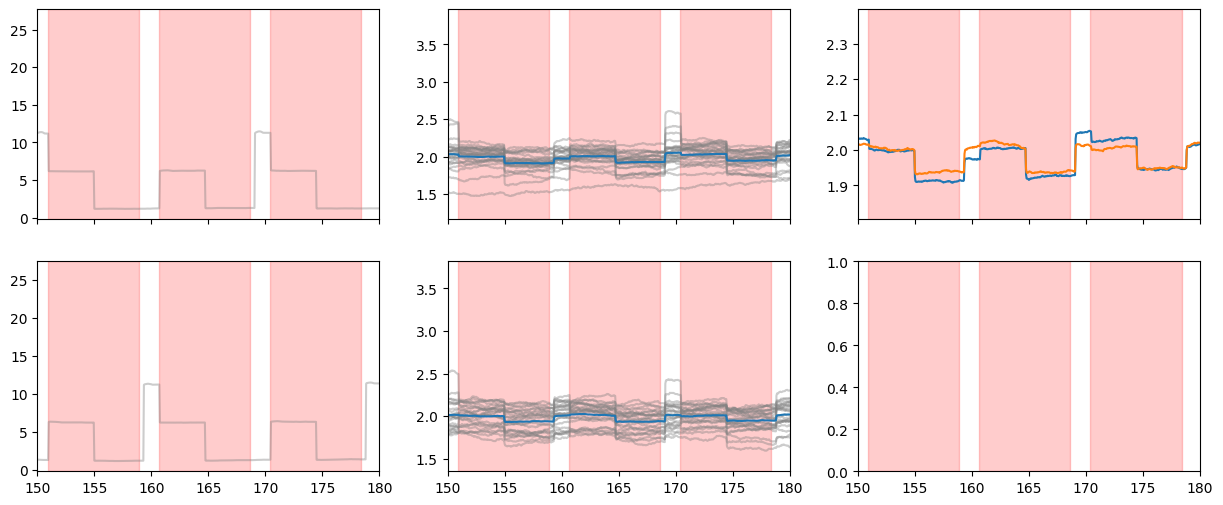

In [ ]:
# plot the weights of all stimulation ids
fig, axs = plt.subplots(2, 3, figsize=(15,6), sharex=True)

for i, (stim_id, motor_ids, ax) in enumerate(zip(data['ids']['stimulation_ids'][2:4], 
                                                 [data['ids']['motor_ids_U'], data['ids']['motor_ids_D']],
                                                  axs)):
    
    # U_mask = np.isin(data['post'], data['ids']['motor_ids_U']) & pre_mask
    # D_mask = np.isin(data['post'], data['ids']['motor_ids_D']) & pre_mask
    # other_mask = pre_mask & ~(U_mask | D_mask)
    
    xs = np.arange(0, data['rs'].shape[1]) * 0.05
    ax[0].plot(xs, data['rs'][stim_id].T, color='gray', alpha=0.4)
    
    for motor_id in motor_ids:
        ax[1].plot(xs, data['rs'][motor_id].T, color='gray', alpha=0.4)
        
    ax[1].plot(xs, np.mean(data['rs'][motor_ids], axis=0))
    
    # ax[0].plot(xs, data['ws'][U_mask].T, color='dodgerblue', alpha=0.8, linewidth=3)
    # ax[0].plot(xs, data['ws'][D_mask].T, color='orchid', alpha=0.8, linewidth=3)
    
    # ax[1].plot(xs, data['ws'][pre_mask].sum(axis=0))
    # ax[1].axhline(1.00917)
    
    # ax.set_title(f'stim_id {i}')
    
    time = 9
    for i, sim_state in enumerate(data['sim states']):
        if sim_state[-1] == 'running':
            time += 0.05
        if sim_state[-1] == 'miss':
            ax[0].axvspan(time, time+8, alpha = 0.2, color='red')
            ax[1].axvspan(time, time+8, alpha = 0.2, color='red')
            ax[2].axvspan(time, time+8, alpha = 0.2, color='red')
            time += 8
        if sim_state[-1] == 'hit':
            ax[0].axvspan(time, time+0.1, alpha = 0.5, color='limegreen')
            ax[1].axvspan(time, time+0.1, alpha = 0.5, color='limegreen')
            ax[2].axvspan(time, time+0.1, alpha = 0.5, color='limegreen')
            time += 0.1
    print(time)
    
for motor_ids in [data['ids']['motor_ids_U'], data['ids']['motor_ids_D']]:
    axs[0][2].plot(xs, np.mean(data['rs'][motor_ids], axis=0))

axs[0][0].set_xlim([150, 180])
# axs[0][0].set_ylim([0,0.1])
# axs[1][0].set_ylim([0,0.1])

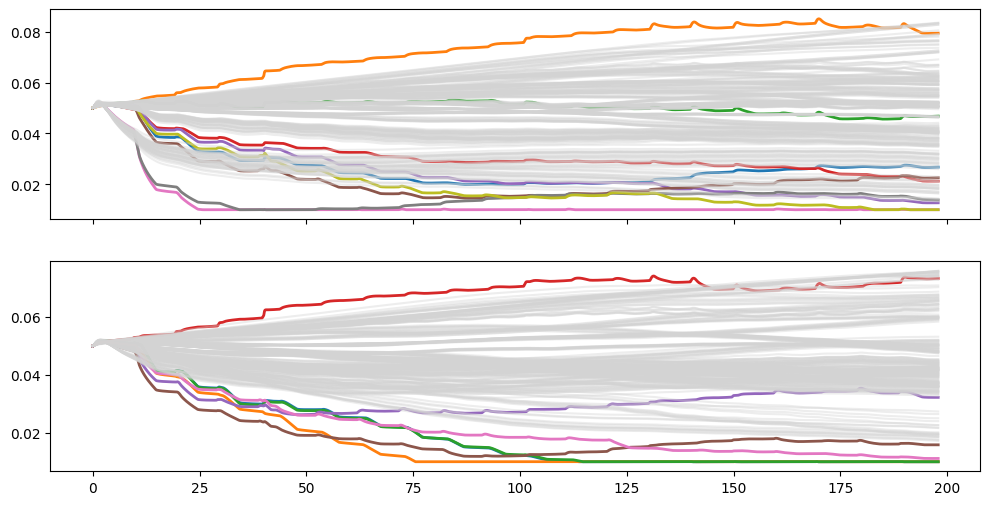

In [ ]:
# plot the weights of all stimulation ids
fig, axs = plt.subplots(2, 1, figsize=(12,6), sharex=True)


U_mask = np.isin(data['post'], data['ids']['motor_ids_U'])
D_mask = np.isin(data['post'], data['ids']['motor_ids_D'])

for ax, post_mask in zip(axs, [U_mask, D_mask]):
    xs = np.arange(0, data['ws'].shape[1]) * 0.05
    
    stim_mask = np.isin(data['pre'], data['ids']['stimulation_ids'])
    
    ax.plot(xs, data['ws'][post_mask & stim_mask].T, alpha=1.0, linewidth=2)
    ax.plot(xs, data['ws'][post_mask & ~stim_mask].T, alpha=0.4, color='lightgray')
    
    


# for stim_id, ax in zip(data['ids']['stimulation_ids'], axs):
    
#     pre_mask = data['pre'] == stim_id
#     print(np.sum(pre_mask))
    
#     U_mask = np.isin(data['post'], data['ids']['motor_ids_U']) & pre_mask
#     D_mask = np.isin(data['post'], data['ids']['motor_ids_D']) & pre_mask
#     other_mask = pre_mask & ~(U_mask | D_mask)
    
#     xs = np.arange(0, data['ws'].shape[1]) * 0.05
#     ax[0].plot(xs, data['ws'][other_mask].T, color='gray', alpha=0.4)
#     ax[0].plot(xs, data['ws'][U_mask].T, color='dodgerblue', alpha=0.4)
#     ax[0].plot(xs, data['ws'][D_mask].T, color='orchid', alpha=0.4)
    
#     ax[1].plot(xs, data['ws'][pre_mask].sum(axis=0))
#     ax[1].axhline(1.2557973994944045)
    
#     time = 300
#     for i, sim_state in enumerate(data['sim states']):
#         if sim_state[-1] == 'running':
#             time += 0.05
#         if sim_state[-1] == 'miss':
#             ax[0].axvspan(time, time+8, alpha = 0.2, color='red')
#             ax[1].axvspan(time, time+8, alpha = 0.2, color='red')
#             time += 8
#         if sim_state[-1] == 'hit':
    #         time += 0.1
    #         ax[0].axvspan(time, time+0.1, alpha = 0.5, color='limegreen')
    #         ax[1].axvspan(time, time+0.1, alpha = 0.5, color='limegreen')
    # print(time)
    

# axs[0][0].set_xlim([950, 980])

In [ ]:
states = data['sim states'][data['sim states']['pong_state'] != 'running']

In [ ]:
np.mean(states[-50:]['pong_state'] == 'hit')

np.float64(0.05)